In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Seguimos con la limpieza del dataset eliminando columnas innecesarias como
# subsecretaria_de_direccion, nombre_de_la_unidad_o_programa, como_se_enteró_del_servicio, sede_que_otorga_el_beneficio, fase_del_emprendimiento
# fase_del_proceso

df = pd.read_csv("/content/CLEAN DATA-atenciones_oficina_publica_de_empleo_ope.csv")
df.head(100)

,Unnamed: 0,edad,sexo,etnia,discapacidad,victima,población_campesina,estado_civil,nivel_escolaridad,cabeza_de_hogar,...,barrio_vereda_ciudadano,comuna_ciudadano,nombre_del_beneficio_otorgado,sede_que_otorga_el_beneficio,fase_del_proceso,fase_del_emprendimiento,como_se_enteró_del_servicio,subsecretaría_dirección,nombre_de_la_unidad_o_programa,fecha_de_beneficio
0,0,45,femenino,otros,no,no,no,soltero,tecnico,si,...,bello,a1-bello / fuera de medellín,9. intermediacion laboral (registro hoja de v...,cam - alcaldia de medellin,1. inscripción,no aplica,evento,subsecretaría de creación y fortalecimiento em...,ope,2017-08-16
1,1,45,femenino,otros,no,no,no,soltero,tecnico,si,...,bello,a1-bello / fuera de medellín,9. intermediacion laboral (registro hoja de v...,cam - alcaldia de medellin,1. inscripción,no aplica,evento,subsecretaría de creación y fortalecimiento em...,ope,2017-08-16
2,2,45,femenino,otros,no,no,no,soltero,tecnico,si,...,bello,a1-bello / fuera de medellín,9. intermediacion laboral (registro hoja de v...,cam - alcaldia de medellin,1. inscripción,no aplica,evento,subsecretaría de creación y fortalecimiento em...,ope,2017-08-16
3,3,25,femenino,otros,no,no,no,casado,tecnologo,no,...,villa hermosa,08-villa hermosa,9. intermediacion laboral (registro hoja de v...,ope villa hermosa,1. inscripción,no aplica,voz a voz,subsecretaría de creación y fortalecimiento em...,ope,2017-09-17
4,4,30,femenino,otros,no,no,no,soltero,bachiller,si,...,villa hermosa,08-villa hermosa,9. intermediacion laboral (registro hoja de v...,ope villa hermosa,1. inscripción,no aplica,evento,subsecretaría de creación y fortalecimiento em...,ope,2017-09-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,55,masculino,otros,no,no,no,casado,primaria,si,...,robledo,07-robledo,9. intermediacion laboral (actualización hoja...,cam - alcaldia de medellin,5. prestación del servicio,no aplica,evento,subsecretaría de creación y fortalecimiento em...,ope,2017-08-17
96,96,55,masculino,otros,no,no,no,casado,primaria,si,...,robledo,07-robledo,9. intermediacion laboral (actualización hoja...,cam - alcaldia de medellin,5. prestación del servicio,no aplica,evento,subsecretaría de creación y fortalecimiento em...,ope,2017-08-17
97,97,55,masculino,otros,no,no,no,casado,primaria,si,...,robledo,07-robledo,9. intermediacion laboral (actualización hoja...,cam - alcaldia de medellin,5. prestación del servicio,no aplica,evento,subsecretaría de creación y fortalecimiento em...,ope,2017-08-17
98,98,55,masculino,otros,no,no,no,casado,primaria,si,...,robledo,07-robledo,2. orientacion (ope),ope robledo,2.orientación,no aplica,feria,subsecretaría de creación y fortalecimiento em...,ope,2017-08-26


In [ ]:
df.drop(columns=['subsecretaría_dirección', 'nombre_de_la_unidad_o_programa', 'como_se_enteró_del_servicio', 'sede_que_otorga_el_beneficio', 'fase_del_emprendimiento', 'fase_del_proceso'], inplace = True)

In [ ]:
df.columns

Index(['Unnamed: 0', 'edad', 'sexo', 'etnia', 'discapacidad', 'victima',
       'población_campesina', 'estado_civil', 'nivel_escolaridad',
       'cabeza_de_hogar', 'orientación_sexual', 'caracterizacion_ciudadano',
       'empleado', 'estrato', 'barrio_vereda_ciudadano', 'comuna_ciudadano',
       'nombre_del_beneficio_otorgado', 'fecha_de_beneficio'],
      dtype='object')

In [ ]:
df.head(5)

,Unnamed: 0,edad,sexo,etnia,discapacidad,victima,población_campesina,estado_civil,nivel_escolaridad,cabeza_de_hogar,orientación_sexual,caracterizacion_ciudadano,empleado,estrato,barrio_vereda_ciudadano,comuna_ciudadano,nombre_del_beneficio_otorgado,fecha_de_beneficio
0,0,45,femenino,otros,no,no,no,soltero,tecnico,si,heterosexual,otro,no,3,bello,a1-bello / fuera de medellín,9. intermediacion laboral (registro hoja de v...,2017-08-16
1,1,45,femenino,otros,no,no,no,soltero,tecnico,si,heterosexual,otro,no,3,bello,a1-bello / fuera de medellín,9. intermediacion laboral (registro hoja de v...,2017-08-16
2,2,45,femenino,otros,no,no,no,soltero,tecnico,si,heterosexual,otro,no,3,bello,a1-bello / fuera de medellín,9. intermediacion laboral (registro hoja de v...,2017-08-16
3,3,25,femenino,otros,no,no,no,casado,tecnologo,no,heterosexual,otro,no,2,villa hermosa,08-villa hermosa,9. intermediacion laboral (registro hoja de v...,2017-09-17
4,4,30,femenino,otros,no,no,no,soltero,bachiller,si,heterosexual,otro,no,2,villa hermosa,08-villa hermosa,9. intermediacion laboral (registro hoja de v...,2017-09-15


In [ ]:
# Identificamos los outliers de las variables numericas (edad, estrato)
# Empezamos con la variable 'edad'
# Calcular Q1, Q3 e IQR
Q1 = df['edad'].quantile(0.25)
Q3 = df['edad'].quantile(0.75)
IQR = Q3 - Q1

# Definir límites inferior y superior
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrar outliers
outliers = df[(df['edad'] < limite_inferior) | (df['edad'] > limite_superior)]

# Eliminar outliers
df_limpio = df[(df['edad'] >= limite_inferior) & (df['edad'] <= limite_superior)]


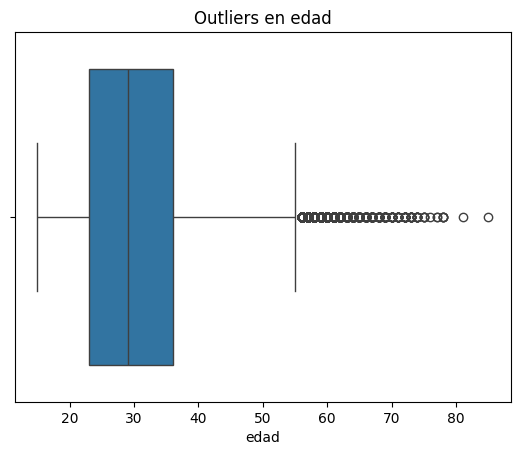

In [ ]:
# Boxplot para ver los outliers
sns.boxplot(x=df['edad'])
plt.title(f"Outliers en {'edad'}")
plt.show()

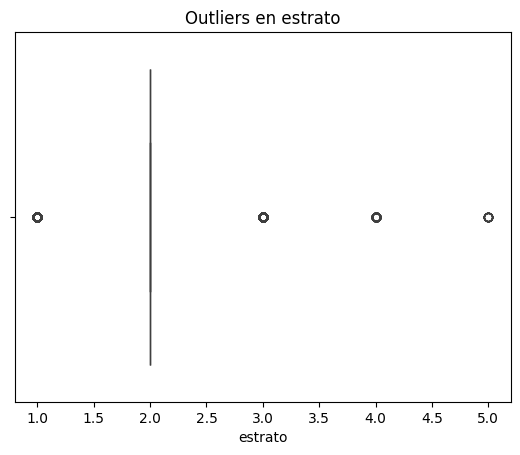

In [ ]:
# Ahora vamos a identificar los outliers en la columna 'estrato'
sns.boxplot(x=df['estrato'])
plt.title(f"Outliers en {'estrato'}")
plt.show()

In [ ]:
df_limpio.to_csv('/content/CLEAN DATA 2-atenciones_oficina_publica_de_empleo_ope.csv')